# Brazil E-Commerce — Sellers Analysis

Analysis of the **Olist `olist_sellers_dataset.csv`** file.

Columns:
- `seller_id` — unique seller identifier
- `seller_zip_code_prefix` — first 5 digits of the zip code
- `seller_city` — city name
- `seller_state` — 2-letter state code

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
sellers = pd.read_csv(
    "Data/olist_sellers_dataset.csv",
    dtype={"seller_zip_code_prefix": str},
)
print(f"Shape: {sellers.shape[0]:,} rows x {sellers.shape[1]} columns")
sellers.head()

Shape: 3,095 rows x 4 columns


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [3]:
sellers.info()
sellers.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   str  
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: str(4)
memory usage: 96.8 KB


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095,3095,3095
unique,3095,2246,611,23
top,3442f8959a84dea7ee197c632cb2df15,14940,sao paulo,SP
freq,1,49,694,1849


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(sellers.isna().sum())

print(f"\nFully duplicated rows: {sellers.duplicated().sum():,}")
print(f"Distinct seller_id: {sellers['seller_id'].nunique():,}")

Missing values per column:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Fully duplicated rows: 0
Distinct seller_id: 3,095


## 3. Sellers by state

Distinct states: 23


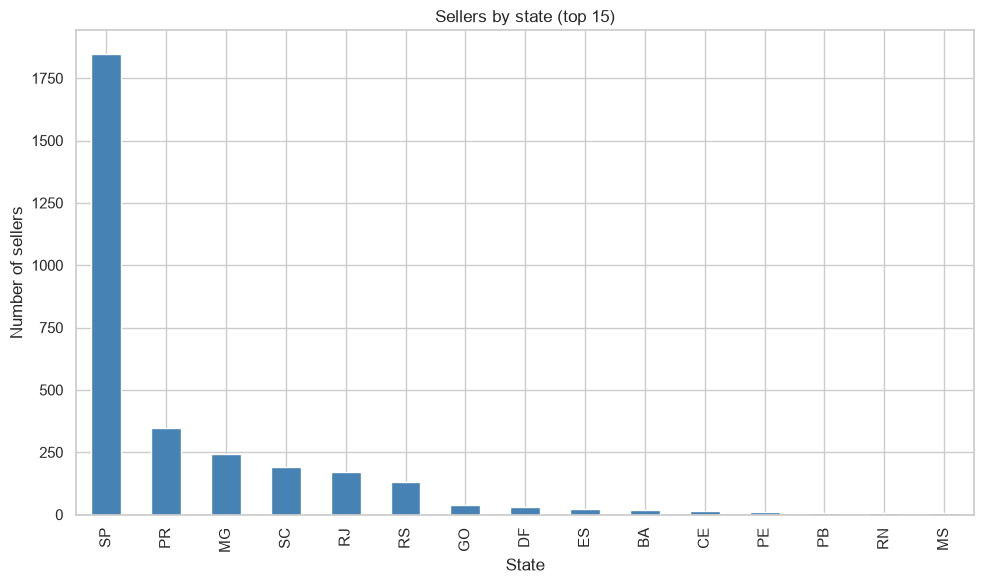

In [5]:
by_state = sellers["seller_state"].value_counts()
print(f"Distinct states: {by_state.shape[0]}")

ax = by_state.head(15).plot(kind="bar", color="steelblue")
ax.set_title("Sellers by state (top 15)")
ax.set_xlabel("State")
ax.set_ylabel("Number of sellers")
plt.tight_layout()
plt.show()

## 4. Sellers by city

Distinct city names: 611


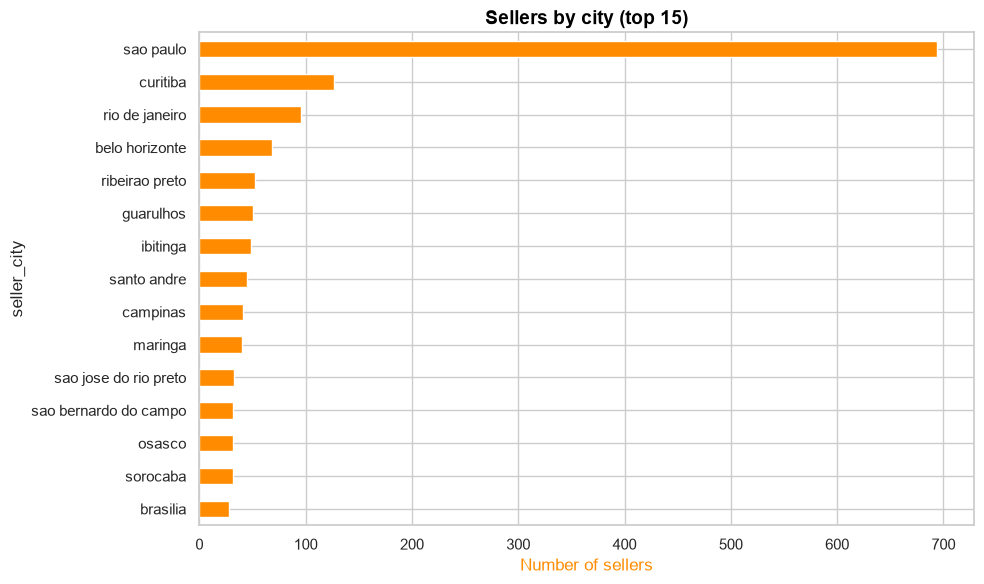

In [6]:
by_city = sellers["seller_city"].value_counts()
print(f"Distinct city names: {by_city.shape[0]:,}")

ax = by_city.head(15).plot(kind="barh", color="darkorange")
ax.invert_yaxis()
ax.set_title("Sellers by city (top 15)", color="black", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of sellers", color="darkorange")
plt.tight_layout()
plt.show()

## 5. Seller vs. customer footprint

Compare where sellers are based against where customers are, to see the geographic
concentration of supply relative to demand.

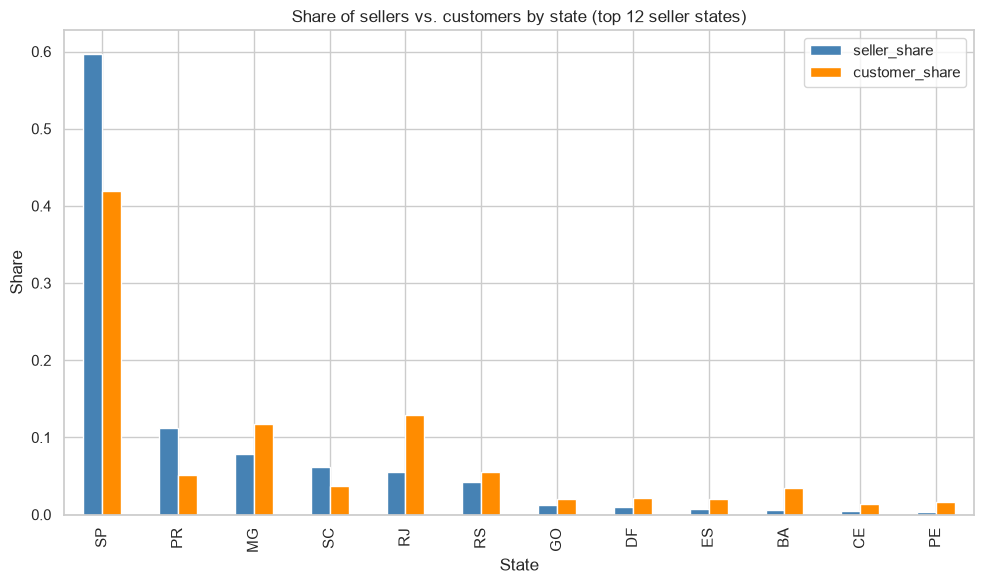

,seller_share,customer_share
SP,0.597415,0.419807
PR,0.112763,0.050734
MG,0.078837,0.117004
SC,0.061389,0.036574
RJ,0.055250,0.129242
RS,0.041680,0.054967
GO,0.012924,0.020314
DF,0.009693,0.021520
ES,0.007431,0.020444
BA,0.006139,0.033990


In [7]:
cust = pd.read_csv("Data/olist_customers_dataset.csv")
seller_share = (sellers["seller_state"].value_counts(normalize=True)).rename("seller_share")
cust_share = (cust["customer_state"].value_counts(normalize=True)).rename("customer_share")

compare = pd.concat([seller_share, cust_share], axis=1).fillna(0).sort_values(
    "seller_share", ascending=False).head(12)
ax = compare.plot(kind="bar", color=["steelblue", "darkorange"])
ax.set_title("Share of sellers vs. customers by state (top 12 seller states)")
ax.set_xlabel("State")
ax.set_ylabel("Share")
plt.tight_layout()
plt.show()
compare

## 6. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- Sellers are even more concentrated in São Paulo than customers — SP is the supply hub.
- Many states have far fewer sellers than their customer share, implying cross-state shipping.
- Seller cities cluster around major Southeast metros (São Paulo, Curitiba, Rio, Belo Horizonte).